## Imports

In [1]:
import os, glob, random
import cv2
import numpy as np
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from sklearn.metrics import precision_recall_fscore_support


## Data Extraction
Runs once to build `Cityscapes_Lean/`

In [2]:
#file paths and parameters

IMG_SRC  = 'leftImg8bit_data/leftImg8bit'
GT_SRC   = 'gtFine_trainvaltest_png_instances/gtFine'
DISP_SRC = 'disparity_trainvaltest/disparity'
OUT_DIR  = 'Cityscapes_Lean'
SIZE     = (512, 256)   # (width, height) — cv2.resize takes W,H order
#there is no test set provided, take 200 and 300 images from train and val respectively for test folder.
LIMITS   = {'train': 1500, 'val': 500, 'test': 500}


In [6]:
#this was difficult to get right - the disparity maps are stored in a custom 16-bit format that 
# needs to be decoded and converted to depth values.
# disparity maps are converted accordingly to match the model input dimensions.
#the directories containg all the source files are fetched by the appneded paths and stored into a newly created direcctory
if not os.path.isdir(os.path.join(OUT_DIR, 'train', 'images')):
    
    random.seed(42)
    
    for split in ['train', 'val', 'test']:
        print(f'Processing {split}...')
        #random subset sample 
        all_imgs      = glob.glob(os.path.join(IMG_SRC, split, '**', '*_leftImg8bit.png'), recursive=True)
        selected_imgs = random.sample(all_imgs, min(len(all_imgs), LIMITS[split]))
        count = 0
        
        for img_path in selected_imgs:
            base_id = os.path.basename(img_path).replace('_leftImg8bit.png', '')
            city    = os.path.basename(os.path.dirname(img_path))
            mask_path = os.path.join(GT_SRC,   split, city, f'{base_id}_gtFine_labelIds.png')
            disp_path = os.path.join(DISP_SRC, split, city, f'{base_id}_disparity.png')
            
            # Redirect the last images from each split into test
            target_split = split
            if split == 'train' and count >= 1300:
                target_split = 'test'
            elif split == 'val' and count >= 200:
                target_split = 'test'
            
            
            img_out  = os.path.join(OUT_DIR, target_split, 'images')
            mask_out = os.path.join(OUT_DIR, target_split, 'masks')
            dep_out  = os.path.join(OUT_DIR, target_split, 'depth')
            
            os.makedirs(img_out, exist_ok=True)
            os.makedirs(mask_out, exist_ok=True)
            os.makedirs(dep_out,  exist_ok=True)

            # 1. Save resized RGB image
            img = cv2.imread(img_path)
            img = cv2.resize(img, SIZE)
            cv2.imwrite(os.path.join(img_out, f'{base_id}.png'), img)

            # 2. Save label mask
            # labelIds.png stores Cityscapes class IDs (0-33) as plain uint8.
            # INTER_NEAREST is essential — other interpolation modes average
            # neighbouring pixels.
            mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
            mask = cv2.resize(mask, SIZE, interpolation=cv2.INTER_NEAREST)
            cv2.imwrite(os.path.join(mask_out, f'{base_id}.png'), mask)

            # 3. Convert Cityscapes disparity maps to normalised depth map.
            
            # Load raw disparity map (16-bit PNG data-points)
            disp_raw = cv2.imread(disp_path, cv2.IMREAD_UNCHANGED).astype(np.float32)

            # Convert to actual depth values
            disparity = np.where(disp_raw > 0, (disp_raw - 1.0) / 256.0, 0)
            # Convert disparity to depth using formula: depth = (baseline * focal_length) / disparity
            # general values -> baseline = 0.2m, focal_length = 2262 pixels
            depth_meters = (0.2 * 2262.0) / disparity

            # Clip depth to limited range (0 to 80 meters)
            depth_meters = np.clip(depth_meters, 0, 80.0)

            # Normalize to [0, 1] for visualization, lets assume max depth of 80m
            depth_normalized = np.nan_to_num(depth_meters / 80.0, nan=0.0)

            # Convert to 8-bit for saving as PNG
            depth_8bit = (depth_normalized * 255).astype(np.uint8)

            # Resize to match model input dimensions
            depth_8bit = cv2.resize(depth_8bit, SIZE, interpolation=cv2.INTER_NEAREST)
            # Save depth map
            cv2.imwrite(os.path.join(dep_out, f'{base_id}.png'), depth_8bit)
            count += 1
            
            
        print(f'Done. Saved {count} images.')
else:
    print(f'{OUT_DIR} already exists - skipping extraction.')


Processing train...


C:\Users\labib\AppData\Local\Temp\ipykernel_36772\2490591199.py:60: RuntimeWarning: divide by zero encountered in divide
  depth_meters = (0.2 * 2262.0) / disparity


Done. Saved 1500 images.
Processing val...
Done. Saved 500 images.
Processing test...
Done. Saved 500 images.


## Dataset & DataLoaders
Follows the [PyTorch custom Dataset tutorial](https://docs.pytorch.org/tutorials/beginner/basics/data_tutorial.html) pattern.


In [ ]:
# Target Cityscapes class IDs: Person(24), Car(26), Truck(27), Motorcycle(32), Bicycle(33)
class_ids = [24, 26, 27, 32, 33]
num_classes = len(class_ids)

# ImageNet mean/std — standard normalisation for natural image CNNs.
# Shifts pixel values to zero-mean/unit-variance which speeds up training convergence.
MEAN = [0.485, 0.456, 0.406]
STD  = [0.229, 0.224, 0.225]


class CityscapesDataset(Dataset):

    # train_transform includes augmentation — randomly flipping and colour-jittering
    # should improve generalisation.
    train_transform = transforms.Compose([
        transforms.RandomHorizontalFlip(p=0.5),         # randomly flip horizontally
        transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),
        transforms.ToTensor(),                           # PIL [0,255] to FloatTensor [0,1]
        transforms.Normalize(mean=MEAN, std=STD),
    ])
    # eval_transform has no augmentation so val/test results are deterministic.
    eval_transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(mean=MEAN, std=STD),
    ])

    def __init__(self, root, split='train'):
        self.img_dir   = os.path.join(root, split, 'images')
        self.mask_dir  = os.path.join(root, split, 'masks')
        self.dep_dir   = os.path.join(root, split, 'depth')
        
        self.is_train  = (split == 'train')
        self.has_depth = os.path.isdir(self.dep_dir) and bool(os.listdir(self.dep_dir))
        
        # Build list of sample IDs from the images folder
        self.filenames = sorted([f.replace('.png','') for f in os.listdir(self.img_dir) if f.endswith('.png')])
        self.img_w, self.img_h = 512, 256

    def __len__(self):
        # Required by DataLoader to know the total number of samples
        return len(self.filenames)

    def __getitem__(self, idx):
        name = self.filenames[idx]

        #1. Normal 8bit images
        
        # Load and transform the RGB image
        img = Image.open(os.path.join(self.img_dir, f'{name}.png')).convert('RGB') 
        img_tensor = (self.train_transform if self.is_train else self.eval_transform)(img)

        #2. Segmentation masks
        

        # This is object detection using segmentation-derived labels.
        mask = Image.open(os.path.join(self.mask_dir, f'{name}.png'))
        mask_np = np.array(mask)

        # Derive bounding boxes from label mask.
        # Masks are classified as grayscale ids.
        # We find all pixels for each class and surround it using boundiong boxes.
        output = []
        for cid in class_ids:
            rows, cols = np.where(mask_np == cid)
            if len(rows) > 0:
                # Compute centre x, centre y, width, height — all normalised 0-1
                output.extend([
                    1.0,
                    (cols.min() + cols.max())/2 / self.img_w, # x centre
                    (rows.min() + rows.max())/2 / self.img_h, # y centre
                    (cols.max() - cols.min())/self.img_w,   # width
                    (rows.max() - rows.min())/self.img_h,   # height
                ])
            else:
                # if object does not exist, set to zero
                output.extend([0.0, 0.0, 0.0, 0.0, 0.0])
            #convert to tensor for predictions 
            output_tensor = torch.tensor(output, dtype=torch.float32)

        #3. Depth Masks
        
        dep_path = os.path.join(self.dep_dir, f'{name}.png')
        
        if self.has_depth and os.path.exists(dep_path):
            dep = Image.open(dep_path).convert('L') #convert to grayscale
            #Use nearest interpolation, to preserve labels
            dep = dep.resize((self.img_w, self.img_h), Image.NEAREST) 
            # convert to tensor and tormalise
            tensor_depth = transforms.ToTensor()(dep)   # [1, H, W] float in [0,1]

        # DataLoader stacks these across a batch automatically:
        # img_tensor [B,3,256,512]  output [B,25]  tensor_depth [B,1,256,512]
        return img_tensor, output_tensor, tensor_depth


# Creat classes for train, validation, and test images in DataLoader
train_ds = CityscapesDataset(OUT_DIR, 'train')
val_ds = CityscapesDataset(OUT_DIR, 'val')
test_ds = CityscapesDataset(OUT_DIR, 'test')

train_loader = DataLoader(train_ds, batch_size=16, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=16)
test_loader = DataLoader(test_ds, batch_size=16)

print(f'Train: {len(train_ds)}  Val: {len(val_ds)}  Test: {len(test_ds)}')


Train: 1500  Val: 500  Test: 500


## Convolutional Neural Network Architecture

This discusses differnt [spatial pool averaging](https://medium.com/@benjybo7/7-pytorch-pool-methods-you-should-be-using-495eb00325d6).

In [ ]:
class MultiTaskCNN(nn.Module):
    def __init__(self, num_classes=num_classes):
        super().__init__()

        # 1. ENCODER 
        # 5 blocks of Conv2d -> BatchNorm2d -> ReLU -> MaxPool2d.
        # input is 256x512. Each MaxPool2d halves spatial resolution, so 5 blocks gives a bottleneck of 8x16 
        # Filter count doubles each block (32->64->128->256->512): 

        self.encoder1 = nn.Sequential(
            # Conv2d: slide filters across image to ecxtract low level patterns eg edges,colours.
            # padding=1 keeps spatial dimensions unchanged after convolution.
            # bias=False because BatchNorm provides its own learnable bias term.
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            # BatchNorm2d: normalises activations across the batch after each conv,
            # prevents gradient explosion/vanishing and acts as light regularisation.
            nn.BatchNorm2d(32),
            # the activation function that introduces non-linearity.
            nn.ReLU(inplace=True),
            # MaxPool2d: takes the max in each 2x2 region, halving spatial resolution.
            # Creates translation invariance (a shifted object still fires same features)
            # and reduces memory so deeper layers can afford more filters.
            nn.MaxPool2d(2)
        )   # [B, 3, 256, 512] -> [B, 32, 128, 256]

        self.encoder2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2)
        )   # [B, 32, 128, 256] -> [B, 64, 64, 128]

        self.encoder3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2)
        )   # [B, 64, 64, 128] -> [B, 128, 32, 64]

        self.encoder4 = nn.Sequential(
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2)
        )   # [B, 128, 32, 64] -> [B, 256, 16, 32]

        self.encoder5 = nn.Sequential(
            nn.Conv2d(256, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2)
        )   # [B, 256, 16, 32] -> [B, 512, 8, 16]  <-- bottleneck
        
        
        # 2. Spatial Pooling
        
        # AdaptiveAvgPool2d(4, 8): compresses 8x16 -> 4x8 by averaging values inside defined windoow.
        # Rationale: bounding box regression needs to know object location.
        # Pure GlobalAvgPool (1x1) discards spatial information, and can cause errors in prediction
        # A 4x8 grid preserves aspect ratio.
        self.spatial_pool = nn.AdaptiveAvgPool2d((4, 8))   # [B,512,8,16] -> [B,512,4,8]
   
        
        # 3. Object detection head
        
        
        # FC 16384->1024: large first layer processes rich spatial feature grid.
        # Dropout: randomly zeros 30% of neurons during training to preven overfitting
        # Sigmoid: maps all outputs to [0,1] to match normalised targets

        self.object_detect = nn.Sequential(
            # Flatten: [B, 512, 4, 8] -> [B, 16384] for fully-connected layers
            nn.Flatten(),
            #block 1
            nn.Linear(512 * 4 * 8, 1024),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            #block 2
            nn.Linear(1024, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            # block 3: output layer
            # NUM_CLASSES*5 values — [object, cx, cy, w, h] per class
            nn.Linear(256, num_classes * 5),
            nn.Sigmoid()
        )   # output: [B, NUM_CLASSES*5]

        # 4. Depth estimation head
        
        
        #  5 upsample blocks restore resolution 8x16 -> 256x512.
        # Rationale: must recover the spatial resolution lost from downsampling in the encoder.
        # Bilinear Upsample chosen over transposed convolution because it is
        # parameter-free and avoids the checkerboard artefacts transposed conv produces.
        self.depth_estimation = nn.Sequential(
            #block 1
            nn.Upsample(scale_factor=2, mode='bilinear'),
            nn.Conv2d(512, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),   # [B, 512, 8, 16] -> [B, 256, 16, 32]
            #block 2
            nn.Upsample(scale_factor=2, mode='bilinear'),
            nn.Conv2d(256, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),   # -> [B, 128, 32, 64]
            #block 3
            nn.Upsample(scale_factor=2, mode='bilinear'),
            nn.Conv2d(128, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),   # -> [B, 64, 64, 128]
            #block 4
            nn.Upsample(scale_factor=2, mode='bilinear'),
            nn.Conv2d(64, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),   # -> [B, 32, 128, 256]
            #block 5
            nn.Upsample(scale_factor=2, mode='bilinear'),
            nn.Conv2d(32, 16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(inplace=True),   # -> [B, 16, 256, 512]
            
            # 1x1 conv reduces to single depth channel with no spatial mixing
            nn.Conv2d(16, 1, kernel_size=1),
            nn.Sigmoid()             # normalised depth output [0,1]
        )   # output: [B, 1, 256, 512]
        
 
    # 5. foward pass through CNN
        

    def forward(self, x):
        x1 = self.encoder1(x)
        x2 = self.encoder2(x1)
        x3 = self.encoder3(x2)
        x4 = self.encoder4(x3)        
        x5 = self.encoder5(x4)   # bottleneck: [B, 512, 8, 16]
        
        
        # Both heads share the same bottleneck features, forcing the encoder to
        # learn representations useful for both detection and depth simultaneously
        depth_output = self.depth_estimation(x5)                   # [B, 1, 256, 512]
        object_detection_output = self.object_detect(self.spatial_pool(x5))   # [B, NUM_CLASSES*5]
        
        
        return object_detection_output, depth_output


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model  = MultiTaskCNN().to(device)
print(f'Using device: {device}')
print(f'Model parameters: {sum(p.numel() for p in model.parameters()):,}')


Using device: cuda
Model parameters: 20,190,458


## Training

### Loss function — nn.MSELoss

MSE computes `mean((predicted - target)^2)`, compatible with normalised range [0,1]

The detection loss has two parts is composed of bounding box loss and if object is detected from the detection head 

Zero_Grad needs to be inlcuded
https://docs.pytorch.org/tutorials/beginner/pytorch_with_examples.html

In [ ]:
# Adam optimiser: adapts the learning rate per parameter using gradient momentum estimates.
# More stable than SGD on small datasets. weight_decay adds L2 regularisation.
optimizer = optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-5)

mse = nn.MSELoss()   # loss function for both detection and depth

epochs = 20
lamda_box   = 10.0   # bbox loss — coordinates are harder to learn than presence
lambda_depth = 1.0   # weight balancing detection vs depth total loss

best_val_loss = float('inf') # track best validation loss

for epoch in range(1, epochs + 1):

    # Training pass
    model.train()
    t_detect = t_depth = 0.0 #training loss params

    for input, output, depth in train_loader:
        # map to gpu
        input, output, depth = input.to(device), output.to(device), depth.to(device)
        
        # Clear gradients from the previous batch.
        # PyTorch accumulates gradients by default — without zeroing, each update
        # would compound gradients from all previous batches, will cause crash from high weights
        optimizer.zero_grad()

        detection_out, depth_out = model(input)   # forward pass through the network

        # 1. Detection loss 
        
        #view reshapes the output to [B, NUM_CLASSES, 5] for easier indexing of presence and bbox values. 
        detection_out_v = detection_out.view(-1, num_classes, 5)
        output_v = output.view(-1, num_classes, 5)
        #presence loss using MSE between predicted and ground truth data
        pres_loss = mse(detection_out_v[:, :, 0], output_v[:, :, 0])
        
        #pytorch average over all classes including when objects are not present
        #perform manual MSE formula
        
        # Mask: only compute bounding box loss where the object is present
        #expand object presence prediction shape across the detection output head
        mask = output_v[:, :, 0].unsqueeze(-1).expand_as(detection_out_v[:, :, 1:]) 
        # mse = sum((mask * (predicted - target)^2)) / number of present objects
        bbox_loss = (mask * (detection_out_v[:, :, 1:] - output_v[:, :, 1:]) ** 2).sum() / (mask.sum() + 1e-6)
        
        
        #accumulate detection losses
        l_det = pres_loss + lamda_box * bbox_loss

        # 2. Depth loss
        
        # Skip if no object detected, no need to compute depth loss 
        if depth.sum() > 0:
            l_dep = mse(depth_out, depth) * lambda_depth 
        else:
            l_dep = torch.tensor(0.0)

        # 3. Backpropagation and weight update
        
        # backward() computes gradient of total loss wrt weight
        (l_det + l_dep).backward()
        # step() applies those gradients to update the weights via Adam rule
        optimizer.step()

        t_detect += l_det.item()   # .item() extracts scalar, frees memory
        t_depth += l_dep.item()

    # 4. Validation pass
    model.eval()   # disables Dropout; BatchNorm uses population statistics
    v_detect = v_depth = 0.0

    with torch.no_grad():   # disables gradient tracking to save memory during eval
        for input, output, depth in val_loader:
            # map to gpu
            input, output, depth = input.to(device), output.to(device), depth.to(device)
            #fowards pass
            detection_out, depth_out = model(input)
            # map out the output to [B, NUM_CLASSES, 5]
            detection_out_v = detection_out.view(-1, num_classes, 5)
            output_v = output.view(-1, num_classes, 5)
            # manually compute detection loss
            pres_loss = mse(detection_out_v[:, :, 0], output_v[:, :, 0])
            mask = output_v[:, :, 0].unsqueeze(-1).expand_as(detection_out_v[:, :, 1:])
            bbox_loss = (mask * (detection_out_v[:, :, 1:] - output_v[:, :, 1:]) ** 2).sum() / (mask.sum() + 1e-6)
            
            #accumulate validation losses
            v_detect += (pres_loss + lamda_box * bbox_loss).item()
            
            if depth.sum() > 0:
                v_depth += mse(depth_out, depth).item()
                

    v_loss_per_batch = (v_detect / len(val_loader)) + (v_depth / len(val_loader))
    
    print(f'Epoch {epoch:02d}/{epochs} | '
          f'Train Det: {t_detect/len(train_loader):.4f}  Dep: {t_depth/len(train_loader):.4f} | '
          f'Val Det: {v_detect/len(val_loader):.4f}  Dep: {v_depth/len(val_loader):.4f}')

    if v_loss_per_batch < best_val_loss:
        best_val_loss = v_loss_per_batch
        torch.save(model.state_dict(), 'best_model.pth')

print(f'Training complete. Best val loss: {best_val_loss:.4f}')


Epoch 01/20 | Train Det: 0.3795  Dep: 0.0822 | Val Det: 0.3460  Dep: 0.0784
Epoch 02/20 | Train Det: 0.3331  Dep: 0.0680 | Val Det: 0.3492  Dep: 0.0683
Epoch 03/20 | Train Det: 0.3115  Dep: 0.0625 | Val Det: 0.3498  Dep: 0.0733
Epoch 04/20 | Train Det: 0.2968  Dep: 0.0595 | Val Det: 0.3474  Dep: 0.0648
Epoch 05/20 | Train Det: 0.2893  Dep: 0.0562 | Val Det: 0.3440  Dep: 0.0669
Epoch 06/20 | Train Det: 0.2830  Dep: 0.0531 | Val Det: 0.3583  Dep: 0.0649
Epoch 07/20 | Train Det: 0.2799  Dep: 0.0509 | Val Det: 0.3515  Dep: 0.0697
Epoch 08/20 | Train Det: 0.2709  Dep: 0.0485 | Val Det: 0.3582  Dep: 0.0607
Epoch 09/20 | Train Det: 0.2703  Dep: 0.0472 | Val Det: 0.3536  Dep: 0.0591
Epoch 10/20 | Train Det: 0.2684  Dep: 0.0452 | Val Det: 0.3656  Dep: 0.0615
Epoch 11/20 | Train Det: 0.2653  Dep: 0.0437 | Val Det: 0.3789  Dep: 0.0700
Epoch 12/20 | Train Det: 0.2600  Dep: 0.0428 | Val Det: 0.3579  Dep: 0.0654
Epoch 13/20 | Train Det: 0.2589  Dep: 0.0419 | Val Det: 0.3565  Dep: 0.0600
Epoch 14/20 

## Metrics

In [7]:
model.load_state_dict(torch.load('best_model.pth', map_location=device, weights_only=True))
model.eval()

vehicle_names = ['Person', 'Car', 'Truck', 'Motorcycle', 'Bicycle']

all_pred, all_output, all_ious = [], [], []
pred_depths, true_depths    = [], []
scores_present = [[] for _ in range(num_classes)]
scores_absent = [[] for _ in range(num_classes)]

#  Computes Intersection over Union (IoU) for two boxes in [cx, cy, w, h]
def compute_iou(pred_box, target_box):

    # 1. Convert Center-Width-Height to Corners (x1, y1, x2, y2)
    def get_corners(box):
        cx, cy, w, h = box
        x1 = cx - (w / 2)
        y1 = cy - (h / 2)
        x2 = cx + (w / 2)
        y2 = cy + (h / 2)
        return x1, y1, x2, y2

    p_x1, p_y1, p_x2, p_y2 = get_corners(pred_box)
    t_x1, t_y1, t_x2, t_y2 = get_corners(target_box)

    # Compute Area of Intersection
    inter_width  = max(0, min(p_x2, t_x2) - max(p_x1, t_x1))
    inter_height = max(0, min(p_y2, t_y2) - max(p_y1, t_y1))
    intersection_area = inter_width * inter_height

    # Compute Area of Union
    # Union = Area1 + Area2 - Intersection
    area_pred   = (p_x2 - p_x1) * (p_y2 - p_y1)
    area_target = (t_x2 - t_x1) * (t_y2 - t_y1)
    union_area  = area_pred + area_target - intersection_area

    return intersection_area / (union_area + 1e-6)

# Switch model to evaluation mode
model.eval()

with torch.no_grad():
    for input, output, depth in test_loader:
        
        input, output, depth = input.to(device), output.to(device), depth.to(device)

        # 1. Forward pass (Match your model head names)
        detection_out_v, depth_out = model(input)

        # 2. Bounding Box
        # Using .view to stretch output onto classes
        detect_np = detection_out_v.view(-1, num_classes, 5).cpu().numpy()
        output_np = output.view(-1, num_classes, 5).cpu().numpy()

        for batch in range(detect_np.shape[0]):
            for objects in range(num_classes):
                # Extracting confidence and coordinates\
                conf = detect_np[batch, objects, 0]
                output_presence = output_np[batch, objects, 0] == 1.0
                prediction_thresh = conf > 0.2 # Confidence threshold

                # Calculate IoU
                if prediction_thresh and output_presence:
                    # detect_np[..., 1:] contains [cx, cy, w, h]
                    iou = compute_iou(detect_np[batch, objects, 1:], output_np[batch, objects, 1:])
                else:
                    iou = 0.0

                all_pred.append(prediction_thresh)
                all_output.append(output_presence)
                all_ious.append(iou)
                
                # Separate scores
                if output_presence:
                    scores_present[objects].append(conf)
                else:
                    scores_absent[objects].append(conf)

        # 3. Depth loss
        # compute onlyb when objects deteced
        valid_mask = depth > 0
        if valid_mask.any():
            # Apply 80.0m scaling (Consistent with Cityscapes meters)
            p_depth = depth_out[valid_mask].cpu().numpy() * 80.0
            t_depth = depth[valid_mask].cpu().numpy() * 80.0
            
            pred_depths.append(p_depth)
            true_depths.append(t_depth)
            
all_pred = np.array(all_pred)
all_output  = np.array(all_output)
all_ious = np.array(all_ious)


print('DETECTION RESULTS')
print("Confidence Calibration (threshold={0.2}):")
print(f"  {'Class':<15} {'Detected':>15} {'Not Detected':>15}")
print('  ' + '-' * 50)

for objects in range(num_classes):
    detected = np.mean(scores_present[objects]) if scores_present[objects] else float('nan')
    not_detected = np.mean(scores_absent[objects])  if scores_absent[objects]  else float('nan')
    print(f'  {vehicle_names[objects]:<14} {detected:>14.3f} {not_detected:>13.3f}')

predictions = all_pred.reshape(-1, num_classes)
outputs  = all_output.reshape(-1, num_classes)
bounding_boxes  = all_ious.reshape(-1, num_classes)

# sklearn handles all TP/FP/FN
for iou_thresh in [0.50, 0.2]:
    
    pred  = predictions.copy()
    matching_output = (predictions == 1) & (outputs == 1)
    pred[matching_output & (bounding_boxes < iou_thresh)] = 0
    
    print(f'  @ IoU >= {iou_thresh}:')
    print(f"  {'Class':<14} {'Prec':>8} {'Rec':>8} {'F1':>8}")
    print('  ' + '-' * 50)
    ps, rs, fs = [], [], []
    for c in range(num_classes):
        precision, recall, f1, _ = precision_recall_fscore_support(outputs[:,c], pred[:,c], average='binary', zero_division=0)
        ps.append(precision); rs.append(recall); fs.append(f1)
        print(f'  {vehicle_names[c]:<14} {precision:>8.3f} {recall:>8.3f} {f1:>8.3f}')
    print(f"  {'MEAN':<14} {np.mean(ps):>8.3f} {np.mean(rs):>8.3f} {np.mean(fs):>8.3f}")



DETECTION RESULTS
Confidence Calibration (threshold={0.2}):
  Class                  Detected    Not Detected
  --------------------------------------------------
  Person                    nan         0.631
  Car                       nan         0.799
  Truck                     nan         0.131
  Motorcycle                nan         0.181
  Bicycle                   nan         0.465
  @ IoU >= 0.5:
  Class              Prec      Rec       F1
  --------------------------------------------------
  Person            0.000    0.000    0.000
  Car               0.000    0.000    0.000
  Truck             0.000    0.000    0.000
  Motorcycle        0.000    0.000    0.000
  Bicycle           0.000    0.000    0.000
  MEAN              0.000    0.000    0.000
  @ IoU >= 0.2:
  Class              Prec      Rec       F1
  --------------------------------------------------
  Person            0.000    0.000    0.000
  Car               0.000    0.000    0.000
  Truck             0.000    

In [8]:
prediction = np.concatenate(pred_depths)
ground_truth = np.clip(np.concatenate(true_depths), 0.1, 80.0)
ratio = np.maximum(prediction / (ground_truth + 1e-6), ground_truth / (prediction + 1e-6))

print('DEPTH ESTIMATION RESULTS')

print(f'RMSE: { np.sqrt (np.mean( (prediction-ground_truth)**2) ):.3f} m')
print(f'RMSE log: {np.sqrt(np.mean((np.log(prediction+1e-6)-np.log(ground_truth))**2)):.4f}')

print(f'Absolute relative error: {np.mean(np.abs(prediction-ground_truth)/ground_truth):.4f}')
print(f'Squared relative error: {np.mean((prediction-ground_truth)**2/ground_truth):.4f}')

#precision accuracy -> is pixels within bounding boxe predictions?
#is 1/4 pixels correct
print(f'threshold accuracy < 1.25: {np.mean(ratio < 1.25)*100:.1f}%')
#is 50% pixels correct
print(f'threshold accuracy < 1.25^2: {np.mean(ratio < 1.25**2)*100:.1f}%')
#is 75% pixels correct
print(f'threshold accuracy < 1.25^3: {np.mean(ratio < 1.25**3)*100:.1f}%')
    



DEPTH ESTIMATION RESULTS
RMSE: 21.129 m
RMSE log: 0.6855
Absolute relative error: 0.5777
Squared relative error: 9.0061
threshold accuracy < 1.25: 18.9%
threshold accuracy < 1.25^2: 39.3%
threshold accuracy < 1.25^3: 60.4%


## Visualisation

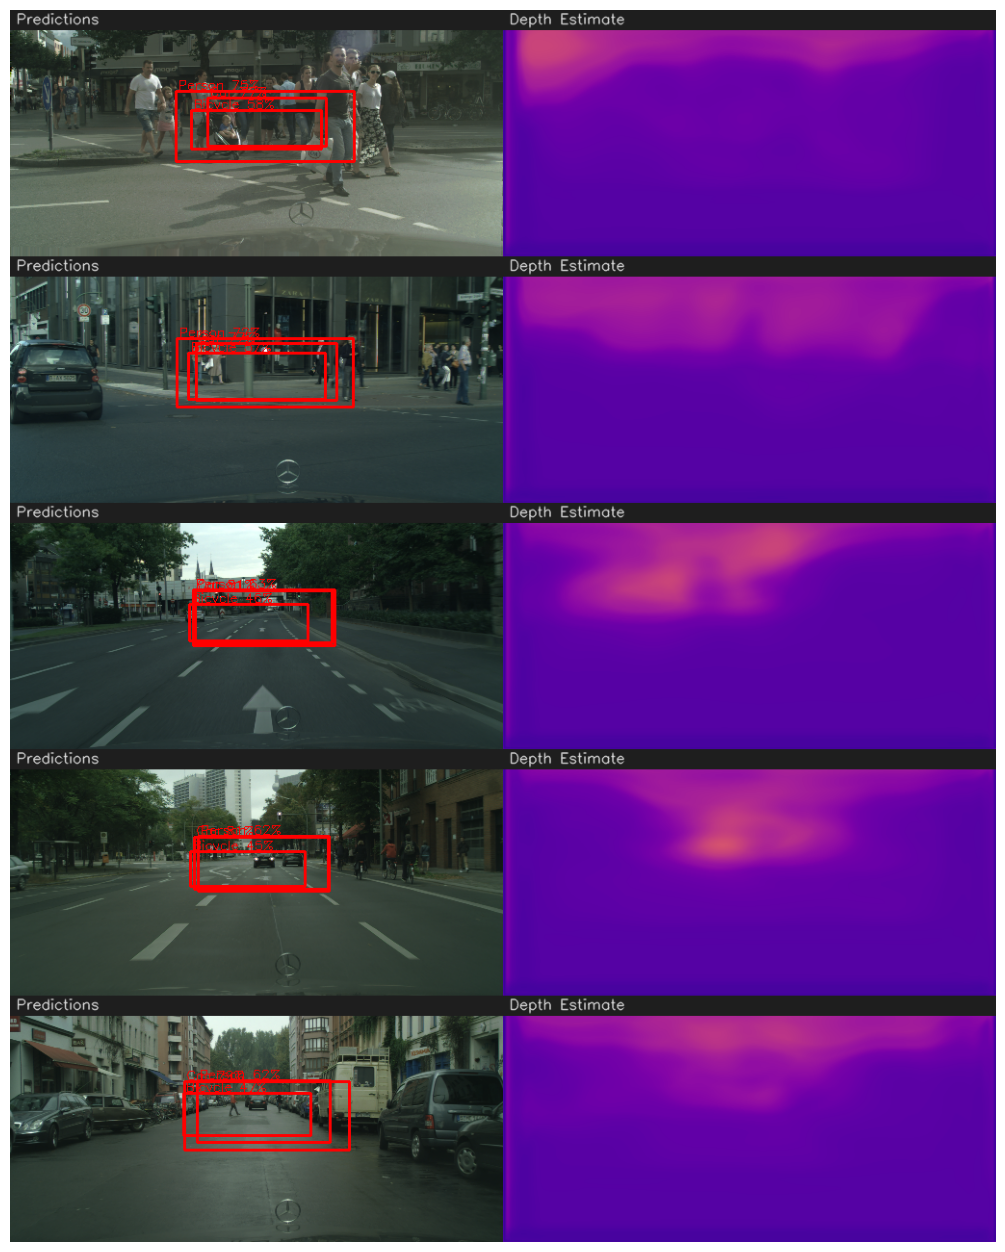

In [9]:
import matplotlib.pyplot as plt
CLASS_BGR = [(255,255,0), (0,255,255), (255,0,255), (0,165,255), (0,255,0)]
FONT = cv2.FONT_HERSHEY_SIMPLEX
N_IMAGES = 5
detection_threshold = 0.30
IoU_threshold = 0.25
rows = []

#reverse normalisation to display matplolib
def unnorm(tensor):
    mean = np.array([0.485, 0.456, 0.406])
    std  = np.array([0.229, 0.224, 0.225])
    img  = tensor.cpu().numpy().transpose(1, 2, 0) * std + mean
    return np.clip(img * 255, 0, 255).astype(np.uint8)[..., ::-1]   # RGB->BGR

def draw_box(canvas, cx, cy, w, h, W, H, color, label):
    x1, y1 = max(0, int((cx-w/2)*W)), max(0, int((cy-h/2)*H))
    x2, y2 = min(W-1, int((cx+w/2)*W)), min(H-1, int((cy+h/2)*H))
    cv2.rectangle(canvas, (x1, y1), (x2, y2), color, 2)
    cv2.putText(canvas, label, (x1+2, y1-2), cv2.FONT_HERSHEY_SIMPLEX, 0.45, color, 1)
    

model.eval()

with torch.no_grad():
    #random images from test set
    for idx in random.sample(range(len(test_ds)), N_IMAGES):
        input, output, _ = test_ds[idx]
        
        # 1. Inference
        det_out, dep_out = model(input.unsqueeze(0).to(device))
        det_np = det_out.view(num_classes, 5).cpu().numpy()
        output_np = output.view(num_classes, 5).cpu().numpy()

        # 2. Unnormalization function
        base = unnorm(input) 
        H, W = base.shape[:2]
        prediction = base.copy()
        
        # 3. Depth
        depth = cv2.applyColorMap((dep_out.squeeze().cpu().numpy() * 255).astype(np.uint8), cv2.COLORMAP_PLASMA)

        for objects in range(num_classes):
            conf      = det_np[objects, 0]
            output_pres  = output_np[objects, 0] == 1.0
            pred_pres = conf > detection_threshold
            
            # draw bounding boxes above threshold
            if pred_pres:
                # comp IoU and line settings
                iou = compute_iou(det_np[objects,1:], output_np[objects,1:]) if output_pres else 0
                color = CLASS_BGR[objects] if (output_pres and iou >= IoU_threshold) else (0,0,255)
                label = f"{vehicle_names[objects]} {conf:.0%}"
                
                if output_pres:
                    label += f" | IoU:{iou:.2f}"
                    
                # draw bounding boxes
                draw_box(prediction, *det_np[objects,1:], W, H, color, label)

        # titles
        for panel, title in [(prediction, 'Predictions'), (depth, 'Depth Estimate')]:
            cv2.rectangle(panel, (0,0), (W,20), (30,30,30), -1)
            cv2.putText(panel, title, (6,14), FONT, 0.5, (220,220,220), 1, cv2.LINE_AA)
            
        # Flip BGR to RGB for Matplotlib display
        rows.append(np.hstack([prediction, depth])[..., ::-1])

plt.figure(figsize=(16,16))
plt.imshow(np.vstack(rows))
plt.axis('off')
plt.show()
